# Notebook 5: Empirical Analysis — ETF Data
**On the Stability of Risk Parity Allocations under Covariance Perturbations**

---

This notebook tests the theory on real market data:
- Download 10+ years of ETF daily returns via `yfinance`
- Compute rolling covariance matrices and rolling RP weights
- Track $\kappa(\Sigma_t)$ and portfolio turnover over time
- Case studies: 2008 financial crisis, 2020 COVID shock
- Test whether periods of high $\kappa$ predict high subsequent turnover

**Sections of paper covered:** §7 (Empirical Analysis)

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from numpy.linalg import norm

from risk_parity import solve_risk_parity, stability_constant, condition_number
from covariance import rolling_covariance, ledoit_wolf_analytical
from plotting import plot_rolling_kappa_and_turnover, savefig

try:
    import yfinance as yf
    HAS_YFINANCE = True
except ImportError:
    HAS_YFINANCE = False
    print('yfinance not installed. Run: pip install yfinance')
    print('Using synthetic data fallback.')

print('Libraries loaded.')

Libraries loaded.


In [2]:
# --- Asset universe: diversified ETFs across asset classes ---
TICKERS = {
    'SPY':  'US Equities',
    'EFA':  'Intl Equities',
    'EEM':  'EM Equities',
    'TLT':  'Long Treasuries',
    'IEF':  'Med Treasuries',
    'LQD':  'Corp Bonds',
    'HYG':  'High Yield',
    'GLD':  'Gold',
    'USO':  'Oil',
    'VNQ':  'REITs',
}

START_DATE = '2007-01-01'
END_DATE   = '2024-12-31'
WINDOW     = 126   # 6-month rolling window (~126 trading days)

print(f'Universe: {len(TICKERS)} ETFs')
print(f'Period:   {START_DATE} to {END_DATE}')
print(f'Window:   {WINDOW} days')

Universe: 10 ETFs
Period:   2007-01-01 to 2024-12-31
Window:   126 days


In [3]:
def load_returns(tickers, start, end):
    """Download adjusted close prices and compute log returns."""
    if not HAS_YFINANCE:
        return _synthetic_returns(len(tickers), 4000)
    prices = yf.download(
        list(tickers.keys()), start=start, end=end,
        auto_adjust=True, progress=False
    )['Close']
    prices = prices.dropna(how='all').ffill().dropna()
    returns = np.log(prices / prices.shift(1)).dropna()
    print(f'Downloaded {len(returns)} trading days, {returns.shape[1]} assets')
    return returns


def _synthetic_returns(n, T):
    """Fallback: generate synthetic returns with time-varying covariance."""
    from covariance import make_covariance, simulate_returns
    # Regime-switching: normal / stressed
    rng = np.random.default_rng(99)
    Sigma_normal = make_covariance(n, kappa=10, seed=1)
    Sigma_stress  = make_covariance(n, kappa=80, seed=2)
    returns_list = []
    for t in range(T):
        crisis = (1500 < t < 1800) or (3000 < t < 3200)  # 2008 / 2020 analogues
        Sig = Sigma_stress if crisis else Sigma_normal
        r = np.random.multivariate_normal(np.zeros(n), Sig)
        returns_list.append(r)
    dates = pd.date_range('2007-01-01', periods=T, freq='B')
    cols = [f'Asset_{i+1}' for i in range(n)]
    return pd.DataFrame(returns_list, index=dates, columns=cols)


returns_df = load_returns(TICKERS, START_DATE, END_DATE)
returns_df.tail(3)

Downloaded 4461 trading days, 10 assets


Ticker,EEM,EFA,GLD,HYG,IEF,LQD,SPY,TLT,USO,VNQ
Date,,,,,,,,,,
2024-12-26,-0.003524,0.004734,0.006728,0.002541,0.000759,0.000934,0.000067,-0.000569,-0.007086,0.002681
2024-12-27,-0.004482,-0.001444,-0.006894,-0.003431,-0.002603,-0.004211,-0.010583,-0.008233,0.009797,-0.010090
2024-12-30,-0.008070,-0.006591,-0.003195,0.001399,0.005847,0.004304,-0.011477,0.008005,0.013049,-0.004970


In [4]:
# Compute rolling risk parity weights and kappa
returns_arr = returns_df.values
T_total, n = returns_arr.shape

Sigmas, indices = rolling_covariance(returns_arr, WINDOW)
dates = returns_df.index[indices]

weights_history  = []
kappa_history    = []
C_history        = []
turnover_history = []

prev_w = None
for Sigma in Sigmas:
    # Ensure SPD (add small regularisation if needed)
    min_eig = np.linalg.eigvalsh(Sigma)[0]
    if min_eig < 1e-8:
        Sigma = Sigma + (1e-6 - min_eig) * np.eye(n)

    w, _ = solve_risk_parity(Sigma)
    kappa = condition_number(Sigma)
    C, _, _ = stability_constant(w, Sigma)

    weights_history.append(w)
    kappa_history.append(kappa)
    C_history.append(C)

    if prev_w is not None:
        turnover_history.append(norm(w - prev_w, 1) / 2)  # one-way turnover
    else:
        turnover_history.append(np.nan)
    prev_w = w

weights_history  = np.array(weights_history)
kappa_history    = np.array(kappa_history)
C_history        = np.array(C_history)
turnover_history = np.array(turnover_history)

print(f'Computed {len(kappa_history)} rolling windows.')
print(f'Kappa range: [{kappa_history.min():.1f}, {kappa_history.max():.1f}]')

Computed 4336 rolling windows.
Kappa range: [201.3, 2775.8]


Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig11_rolling_kappa_turnover.png


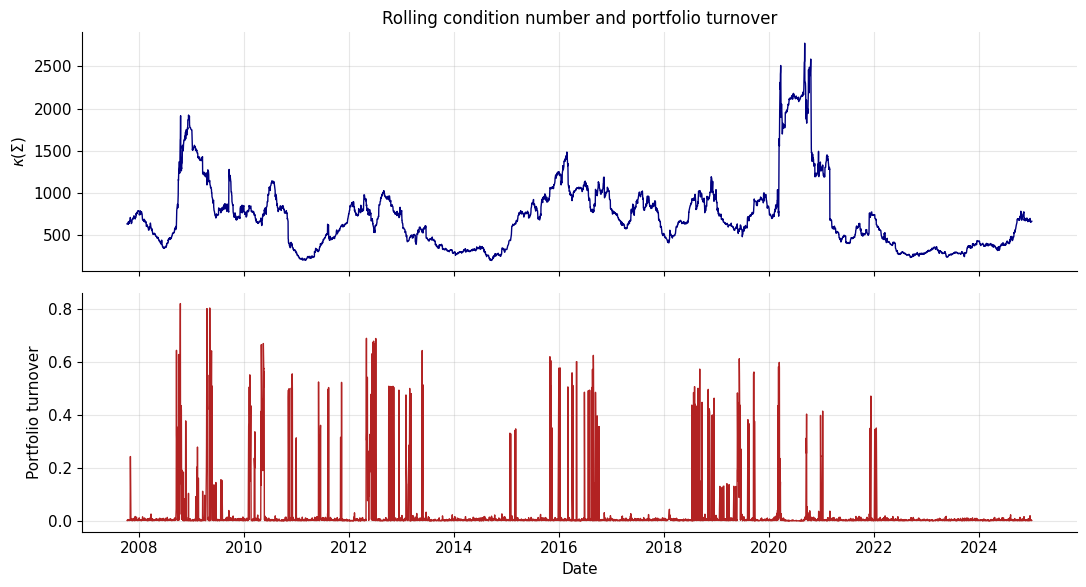

In [5]:
# Main empirical figure: rolling kappa and turnover
fig = plot_rolling_kappa_and_turnover(
    dates, kappa_history, turnover_history,
    title='Rolling condition number and portfolio turnover'
)
savefig('fig11_rolling_kappa_turnover')
plt.show()

Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig12_rolling_weights.png


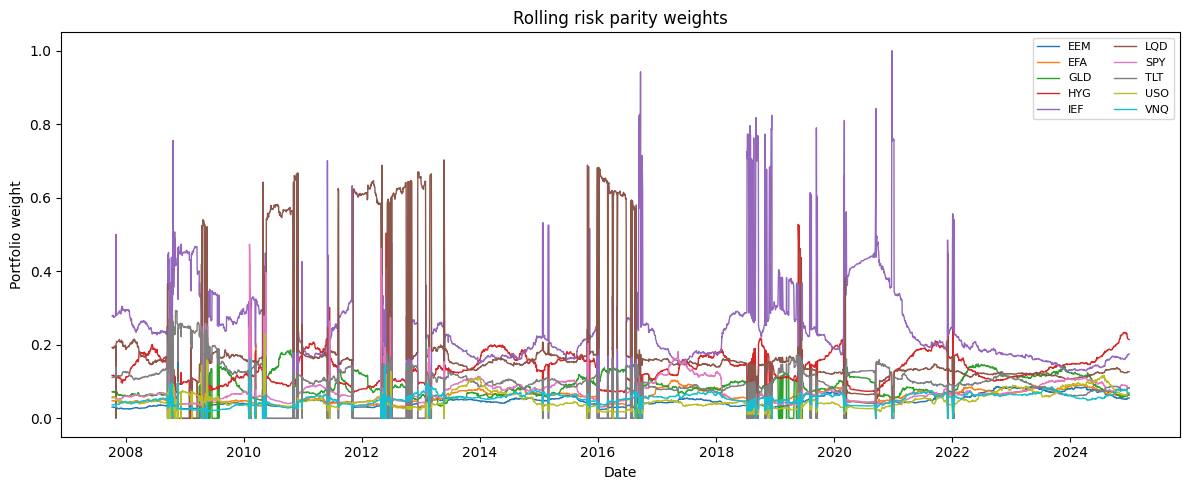

In [6]:
# Rolling weight paths
asset_names = list(returns_df.columns)
fig, ax = plt.subplots(figsize=(12, 5))
for i, name in enumerate(asset_names):
    ax.plot(dates, weights_history[:, i], linewidth=1, label=name)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio weight')
ax.set_title('Rolling risk parity weights')
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
savefig('fig12_rolling_weights')
plt.show()

Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig13_kappa_crises.png


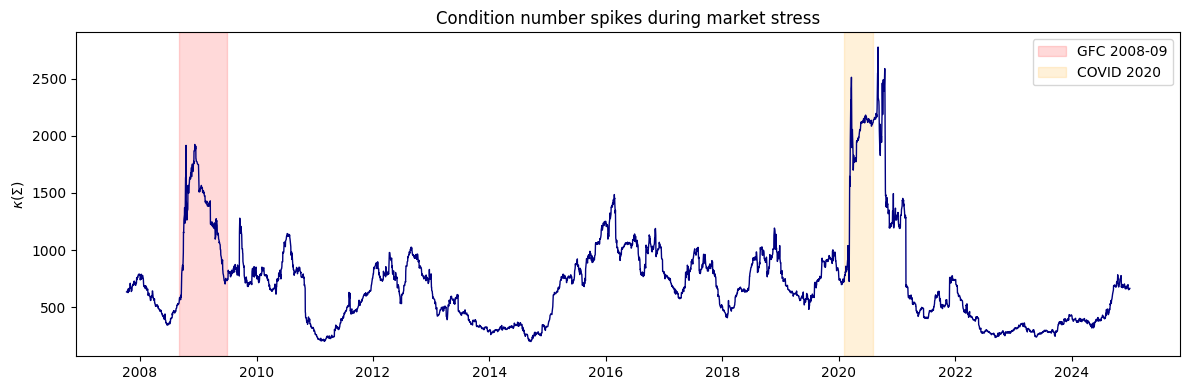

In [7]:
# Case studies: mark 2008 and 2020 crisis periods
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(dates, kappa_history, color='navy', linewidth=1)

# Shade crisis periods
ax.axvspan(pd.Timestamp('2008-09-01'), pd.Timestamp('2009-06-30'),
           alpha=0.15, color='red', label='GFC 2008-09')
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-07-31'),
           alpha=0.15, color='orange', label='COVID 2020')
ax.set_ylabel(r'$\kappa(\Sigma)$')
ax.set_title('Condition number spikes during market stress')
ax.legend()
plt.tight_layout()
savefig('fig13_kappa_crises')
plt.show()

Saved: /Users/rohan/Desktop/ML Projects/Risk-Parity-Allocation-Instability/notebooks/../src/../figures/fig14_kappa_predicts_turnover.png


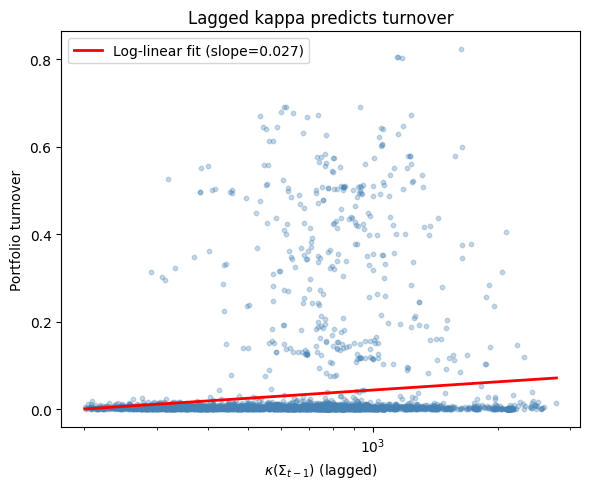

Spearman correlation: 0.0135  (p=3.75e-01)


In [8]:
# Scatter: does lagged kappa predict turnover?
valid = ~np.isnan(turnover_history)
kappa_lagged = np.roll(kappa_history, 1)
kappa_lagged[0] = np.nan
mask = valid & ~np.isnan(kappa_lagged)

plt.figure(figsize=(6, 5))
plt.scatter(kappa_lagged[mask], turnover_history[mask],
            alpha=0.3, s=10, color='steelblue')

# Fit log-linear trend
lk = np.log(kappa_lagged[mask])
lt = turnover_history[mask]
coeffs = np.polyfit(lk, lt, 1)
x_fit = np.linspace(lk.min(), lk.max(), 100)
plt.plot(np.exp(x_fit), np.polyval(coeffs, x_fit),
         'r-', linewidth=2, label=f'Log-linear fit (slope={coeffs[0]:.3f})')

plt.xlabel(r'$\kappa(\Sigma_{t-1})$ (lagged)')
plt.ylabel('Portfolio turnover')
plt.title('Lagged kappa predicts turnover')
plt.xscale('log')
plt.legend()
plt.tight_layout()
savefig('fig14_kappa_predicts_turnover')
plt.show()

from scipy.stats import spearmanr
rho_s, pval = spearmanr(kappa_lagged[mask], turnover_history[mask])
print(f'Spearman correlation: {rho_s:.4f}  (p={pval:.2e})')

In [9]:
# Save results to disk for paper figures
results_df = pd.DataFrame({
    'date': dates,
    'kappa': kappa_history,
    'C': C_history,
    'turnover': turnover_history,
})
results_df.to_csv('../results/empirical_results.csv', index=False)
np.save('../results/weights_history.npy', weights_history)
print('Results saved to ../results/')

Results saved to ../results/
